# Spatial Weights

In [1]:
import os
import sys

In [2]:
sys.path.append(os.path.abspath(".."))
import libpysal

In [3]:
libpysal.examples.available()

,Name,Description,Installed
0,10740,"Albuquerque, New Mexico, Census 2000 Tract Dat...",True
1,AirBnB,"Airbnb rentals, socioeconomics, and crime in C...",True
2,Atlanta,"Atlanta, GA region homicide counts and rates",False
3,Baltimore,Baltimore house sales prices and hedonics,True
4,Bostonhsg,Boston housing and neighborhood data,False
...,...,...,...
94,taz,Traffic Analysis Zones in So. California,True
95,tokyo,Tokyo Mortality data,True
96,us_income,Per-capita income for the lower 48 US states 1...,True
97,virginia,Virginia counties shapefile,True


In [4]:
libpysal.examples.explain("mexico")

mexico

Decennial per capita incomes of Mexican states 1940-2000
--------------------------------------------------------

* mexico.csv: attribute data. (n=32, k=13)
* mexico.gal: spatial weights in GAL format.
* mexicojoin.shp: Polygon shapefile. (n=32)

Data used in Rey, S.J. and M.L. Sastre Gutierrez. (2010) "Interregional inequality dynamics in Mexico." Spatial Economic Analysis, 5: 277-298.



## Weights from GeoDataFrames

In [5]:
import geopandas

pth = libpysal.examples.get_path("mexicojoin.shp")
gdf = geopandas.read_file(pth)

from libpysal.weights import KNN, Queen, Rook

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

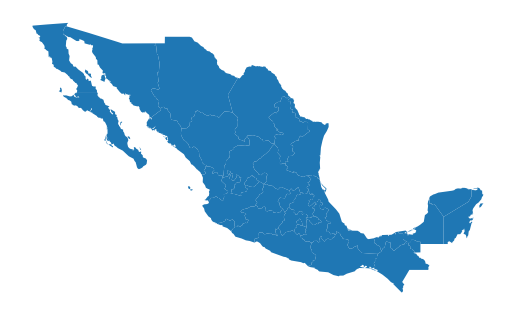

In [7]:
ax = gdf.plot()
ax.set_axis_off()

### Contiguity Weights

The first set of spatial weights we illustrate use notions of contiguity to define neighboring observations. **Rook** neighbors are those states that share an edge on their respective borders:

In [8]:
w_rook = Rook.from_dataframe(gdf)

/var/folders/2f/fhks6w_d0k556plcv3rfmshw0000gn/T/ipykernel_3470/1853022568.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_rook = Rook.from_dataframe(gdf)


In [9]:
w_rook.n

32

In [10]:
w_rook.pct_nonzero

12.6953125

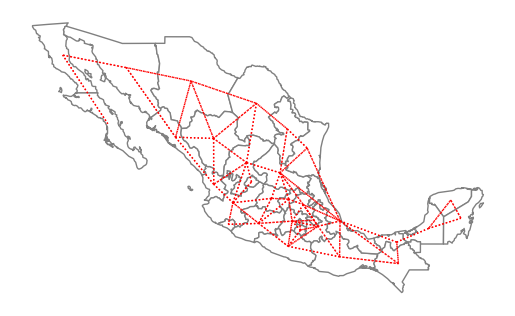

In [11]:
ax = gdf.plot(edgecolor="grey", facecolor="w")
f, ax = w_rook.plot(
    gdf,
    ax=ax,
    edge_kws=dict(color="r", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)
ax.set_axis_off()

In [12]:
gdf.head()

,POLY_ID,AREA,CODE,NAME,PERIMETER,ACRES,HECTARES,PCGDP1940,PCGDP1950,PCGDP1960,...,GR9000,LPCGDP40,LPCGDP50,LPCGDP60,LPCGDP70,LPCGDP80,LPCGDP90,LPCGDP00,TEST,geometry
0,1,7.252751e+10,MX02,Baja California Norte,2040312.385,1.792187e+07,7252751.376,22361.0,20977.0,17865.0,...,0.05,4.35,4.32,4.25,4.40,4.47,4.43,4.48,1.0,"MULTIPOLYGON (((-113.13972 29.01778, -113.2405..."
1,2,7.225988e+10,MX03,Baja California Sur,2912880.772,1.785573e+07,7225987.769,9573.0,16013.0,16707.0,...,0.00,3.98,4.20,4.22,4.39,4.46,4.41,4.42,2.0,"MULTIPOLYGON (((-111.20612 25.80278, -111.2302..."
2,3,2.731957e+10,MX18,Nayarit,1034770.341,6.750785e+06,2731956.859,4836.0,7515.0,7621.0,...,-0.05,3.68,3.88,3.88,4.04,4.13,4.11,4.06,3.0,"MULTIPOLYGON (((-106.62108 21.56531, -106.6475..."
3,4,7.961008e+10,MX14,Jalisco,2324727.436,1.967200e+07,7961008.285,5309.0,8232.0,9953.0,...,0.03,3.73,3.92,4.00,4.21,4.32,4.30,4.33,4.0,"POLYGON ((-101.5249 21.85664, -101.5883 21.772..."
4,5,5.467030e+09,MX01,Aguascalientes,313895.530,1.350927e+06,546702.985,10384.0,6234.0,8714.0,...,0.13,4.02,3.79,3.94,4.21,4.32,4.32,4.44,5.0,"POLYGON ((-101.8462 22.01176, -101.9653 21.883..."


In [13]:
w_rook.neighbors[0]  # the first location has two neighbors at locations 1 and 22

[1, 22]

In [14]:
gdf["NAME"][[0, 1, 22]]

0     Baja California Norte
1       Baja California Sur
22                   Sonora
Name: NAME, dtype: str

So, Baja California Norte has 2 rook neighbors: Baja California Sur and Sonora.

**Queen** neighbors are based on a more inclusive condition that requires only a shared vertex between two states:

In [15]:
w_queen = Queen.from_dataframe(gdf)

/var/folders/2f/fhks6w_d0k556plcv3rfmshw0000gn/T/ipykernel_3470/1138514842.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = Queen.from_dataframe(gdf)


In [16]:
w_queen.n == w_rook.n

True

In [17]:
(w_queen.pct_nonzero > w_rook.pct_nonzero) == (w_queen.n == w_rook.n)

True

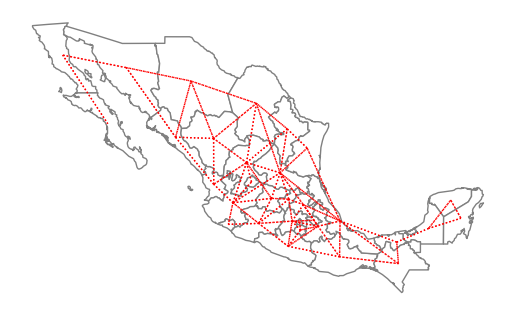

In [18]:
ax = gdf.plot(edgecolor="grey", facecolor="w")
f, ax = w_queen.plot(
    gdf,
    ax=ax,
    edge_kws=dict(color="r", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)
ax.set_axis_off()

In [19]:
w_queen.histogram

[(np.int64(1), np.int64(1)),
 (np.int64(2), np.int64(6)),
 (np.int64(3), np.int64(6)),
 (np.int64(4), np.int64(6)),
 (np.int64(5), np.int64(5)),
 (np.int64(6), np.int64(2)),
 (np.int64(7), np.int64(3)),
 (np.int64(8), np.int64(2)),
 (np.int64(9), np.int64(1))]

In [20]:
w_rook.histogram

[(np.int64(1), np.int64(1)),
 (np.int64(2), np.int64(6)),
 (np.int64(3), np.int64(7)),
 (np.int64(4), np.int64(7)),
 (np.int64(5), np.int64(3)),
 (np.int64(6), np.int64(4)),
 (np.int64(7), np.int64(3)),
 (np.int64(8), np.int64(1))]

In [21]:
c9 = [idx for idx, c in w_queen.cardinalities.items() if c == 9]

In [22]:
gdf["NAME"][c9]

28    San Luis Potosi
Name: NAME, dtype: str

In [23]:
w_rook.neighbors[28]

[5, 6, 7, 27, 29, 30, 31]

In [24]:
w_queen.neighbors[28]

[3, 5, 6, 7, 24, 27, 29, 30, 31]

(np.float64(-105.0), np.float64(-95.0), np.float64(21.0), np.float64(26.0))

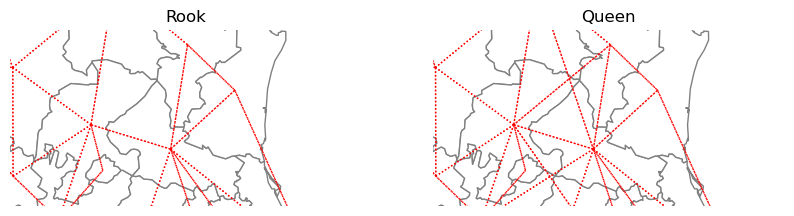

In [25]:
import numpy as np

f, ax = plt.subplots(1, 2, figsize=(10, 6), subplot_kw=dict(aspect="equal"))
gdf.plot(edgecolor="grey", facecolor="w", ax=ax[0])
w_rook.plot(
    gdf,
    ax=ax[0],
    edge_kws=dict(color="r", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)
ax[0].set_title("Rook")
ax[0].axis(np.asarray([-105.0, -95.0, 21, 26]))

ax[0].axis("off")
gdf.plot(edgecolor="grey", facecolor="w", ax=ax[1])
w_queen.plot(
    gdf,
    ax=ax[1],
    edge_kws=dict(color="r", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)
ax[1].set_title("Queen")
ax[1].axis("off")
ax[1].axis(np.asarray([-105.0, -95.0, 21, 26]))

In [26]:
w_knn = KNN.from_dataframe(gdf, k=4)

In [27]:
w_knn.histogram

[(np.int64(4), np.int64(32))]

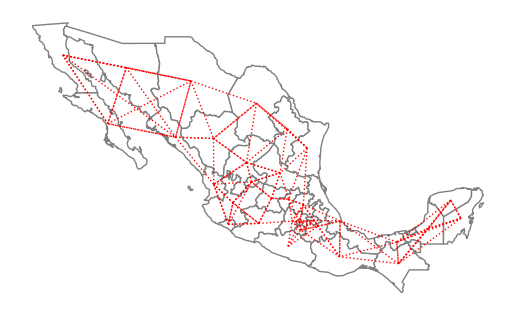

In [28]:
ax = gdf.plot(edgecolor="grey", facecolor="w")
f, ax = w_knn.plot(
    gdf,
    ax=ax,
    edge_kws=dict(color="r", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)
ax.set_axis_off()

## Weights from shapefiles (without geopandas)

In [29]:
pth = libpysal.examples.get_path("mexicojoin.shp")
from libpysal.weights import KNN, Queen, Rook

In [30]:
w_queen = Queen.from_shapefile(pth)

/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/io/iohandlers/pyShpIO.py:232: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  shp = self.type(vertices, holes)
/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/cg/shapes.py:1405: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._part_rings = list(map(Ring, vertices))
/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/io/iohandlers/pyShpIO.py:247: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  shp = self.type(vertices)
/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/cg/shapes.py:1408: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._part

In [31]:
w_rook = Rook.from_shapefile(pth)

In [32]:
w_knn1 = KNN.from_shapefile(pth)

/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/cg/shapes.py:1279: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._centroid = Point((cx, cy))
/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


The warning alerts us to the fact that using a first nearest neighbor criterion to define the neighbors results in a connectivity graph that has more than a single component. In this particular case there are 2 components which can be seen in the following plot:

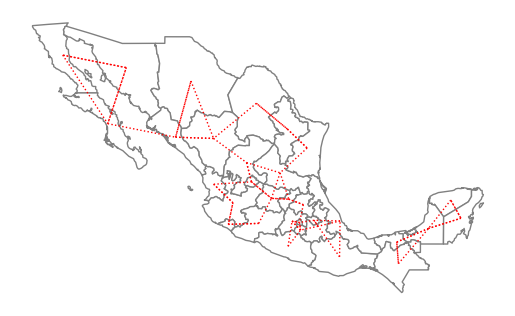

In [33]:
ax = gdf.plot(edgecolor="grey", facecolor="w")
f, ax = w_knn1.plot(
    gdf,
    ax=ax,
    edge_kws=dict(color="r", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)
ax.set_axis_off()

The two components are separated in the southern part of the country, with the smaller component to the east and the larger component running through the rest of the country to the west. For certain types of spatial analytical methods, it is necessary to have a adjacency structure that consists of a single component. To ensure this for the case of Mexican states, we can increase the number of nearest neighbors to three:

In [34]:
w_knn3 = KNN.from_shapefile(pth, k=3)

/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/io/iohandlers/pyShpIO.py:232: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  shp = self.type(vertices, holes)
/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/cg/shapes.py:1405: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._part_rings = list(map(Ring, vertices))
/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/cg/shapes.py:1279: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._centroid = Point((cx, cy))
/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/io/iohandlers/pyShpIO.py:247: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  shp

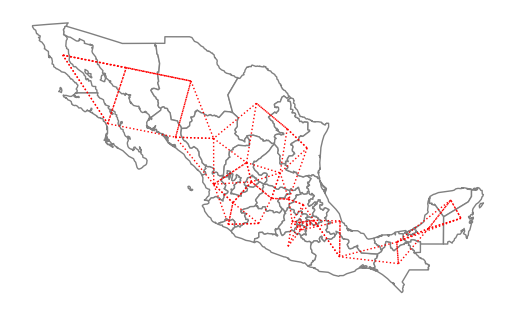

In [35]:
ax = gdf.plot(edgecolor="grey", facecolor="w")
f, ax = w_knn3.plot(
    gdf,
    ax=ax,
    edge_kws=dict(color="r", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)
ax.set_axis_off()

## Lattice Weights

In [36]:
from libpysal.weights import lat2W

In [37]:
w = lat2W(4, 3)

In [38]:
w.n

12

In [39]:
w.pct_nonzero

23.61111111111111

In [40]:
w.neighbors

{0: [3, 1],
 3: [0, 6, 4],
 1: [0, 4, 2],
 4: [1, 3, 7, 5],
 2: [1, 5],
 5: [2, 4, 8],
 6: [3, 9, 7],
 7: [4, 6, 10, 8],
 8: [5, 7, 11],
 9: [6, 10],
 10: [7, 9, 11],
 11: [8, 10]}

## Handling nonplanar geometries

In [41]:
rs = libpysal.examples.get_path("map_RS_BR.shp")

In [42]:
import geopandas as gpd

In [43]:
rs_df = gpd.read_file(rs)
wq = libpysal.weights.Queen.from_dataframe(rs_df)

/var/folders/2f/fhks6w_d0k556plcv3rfmshw0000gn/T/ipykernel_3470/750426907.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = libpysal.weights.Queen.from_dataframe(rs_df)
/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 30 disconnected components.
 There are 29 islands with ids: 0, 4, 23, 27, 80, 94, 101, 107, 109, 119, 122, 139, 169, 175, 223, 239, 247, 253, 254, 255, 256, 261, 276, 291, 294, 303, 321, 357, 374.
  W.__init__(self, neighbors, ids=ids, **kw)


In [44]:
len(wq.islands)

29

In [45]:
wq[0]

{}

In [46]:
wf = libpysal.weights.fuzzy_contiguity(rs_df)

In [47]:
wf.islands

[]

In [48]:
wf[0]

{239: 1.0, 59: 1.0, 152: 1.0, 23: 1.0}

/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/weights/weights.py:1482: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.loc[neighbors].centroid
/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/weights/weights.py:1494: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.centroid


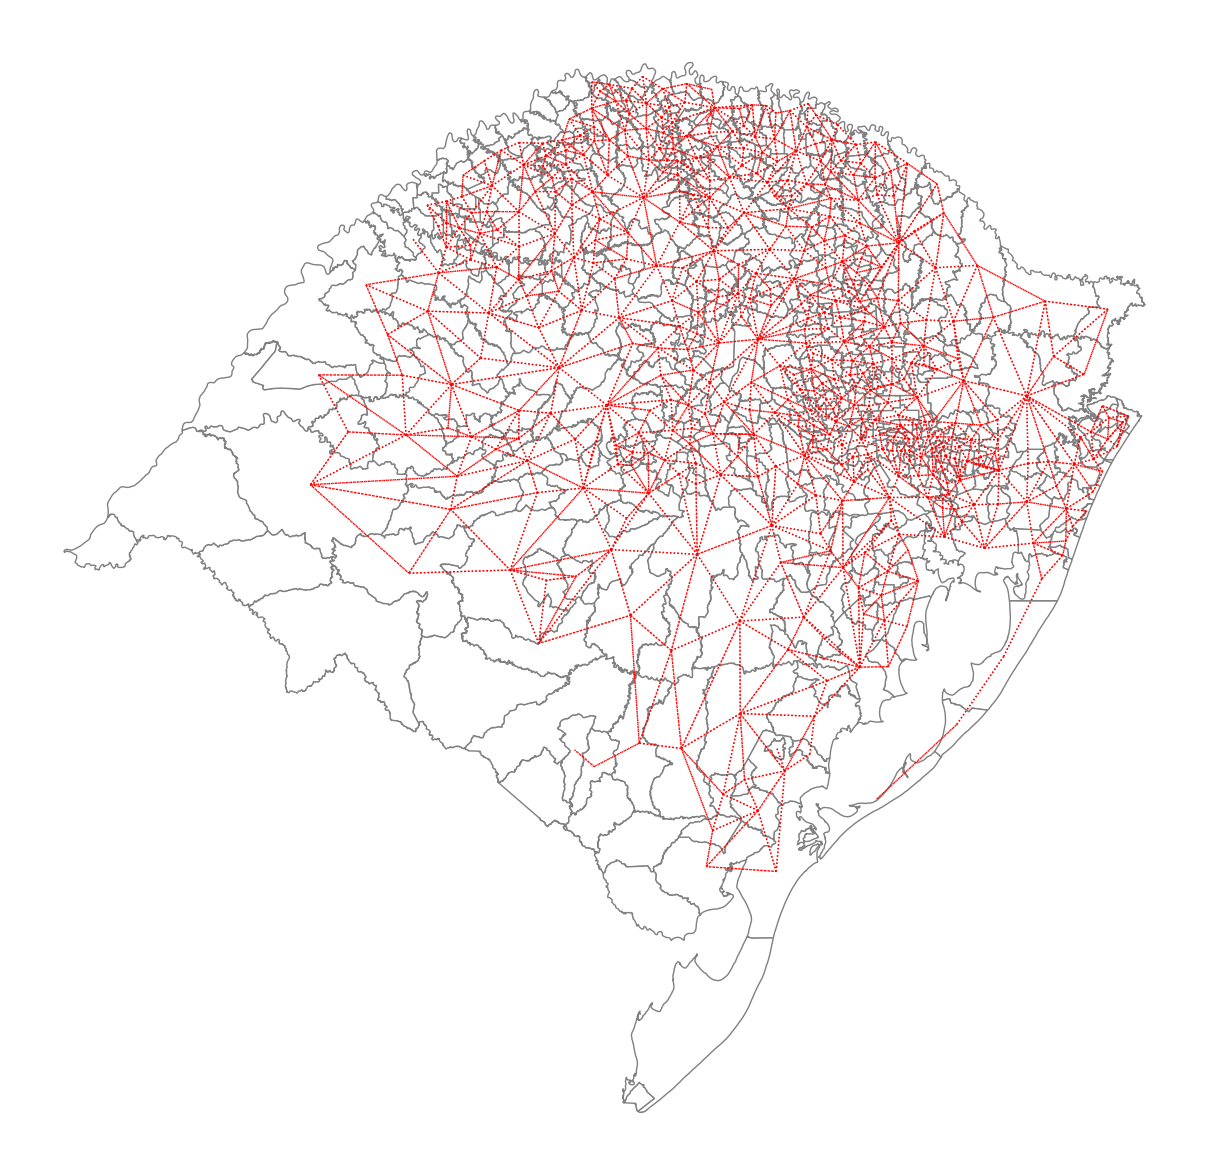

In [49]:
plt.rcParams["figure.figsize"] = (20, 15)
ax = rs_df.plot(edgecolor="grey", facecolor="w")
f, ax = wq.plot(
    rs_df,
    ax=ax,
    edge_kws=dict(color="r", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)

ax.set_axis_off()

/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/weights/weights.py:1482: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.loc[neighbors].centroid
/Users/martin/dev/pysal/.pixi/envs/default/lib/python3.14/site-packages/libpysal/weights/weights.py:1494: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.centroid


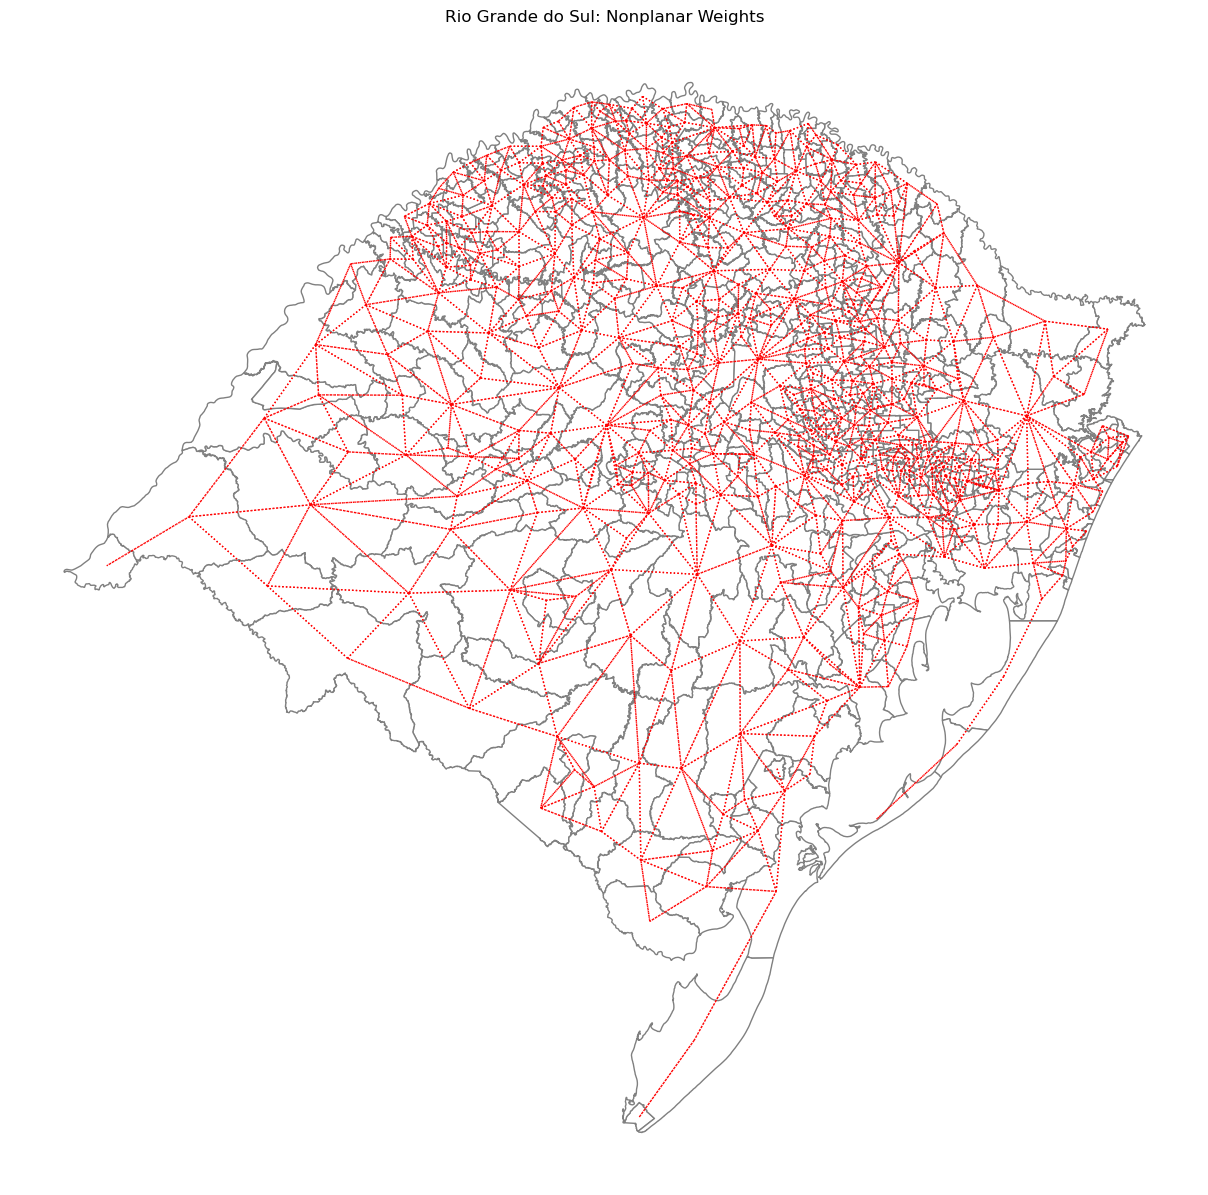

In [ ]:
ax = rs_df.plot(edgecolor="grey", facecolor="w")
f, ax = wf.plot(
    rs_df,
    ax=ax,
    edge_kws=dict(color="r", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)
ax.set_title("Rio Grande do Sul: Nonplanar Weights")
ax.set_axis_off()